# Homework 1: Gradient descent

In [1]:
# imports cell

import itertools
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable

In [2]:
def backtrack_learning_rate(f, nabla_f, theta, current, beta, armijo_c):
    eta = current
    grad = nabla_f(theta)
    g_norm2 = np.dot(grad, grad)

    lhs = f(theta - eta * grad)
    rhs = f(theta) - armijo_c * eta * g_norm2
    it = 0

    # Reduce eta while Armijo condition is NOT satisfied (lhs > rhs means insufficient decrease)
    while lhs > rhs:
        eta *= beta
        it += 1
        lhs = f(theta - eta * grad)
        rhs = f(theta) - (armijo_c * eta * g_norm2)

    return eta, it


def gradient_descent(
    f,
    nabla_f,
    eta0,
    theta0,
    maxit: int = 25,
    with_backtracking: bool = False,
    beta: float | None = None,
    armijo_c: float | None = None,
):
    """Gradient descent with constant or backtracking step size."""
    theta = theta0
    eta = eta0
    params = [theta]
    values = [f(theta)]

    for _ in range(maxit):
        grad = nabla_f(theta)
        if with_backtracking:
            if beta is None or armijo_c is None:
                raise ValueError("Both `beta` and `armijo_c` must be provided when using backtracking")
            eta, it = backtrack_learning_rate(f, nabla_f, theta, eta, beta, armijo_c)
        theta = theta - (eta * grad)

        params.append(theta)
        values.append(f(theta))

    return theta, params, values


def gradient_descent_exact_ls(f, nabla_f, theta0, maxit: int = 25):
    """Gradient descent with exact line search for quadratic objectives.

    Uses the closed-form optimal step η* = gᵀg / gᵀAg, where Ag is obtained
    by evaluating nabla_f(g) — valid when nabla_f is linear (i.e. nabla_f(x) = Ax).
    """
    theta = np.asarray(theta0, dtype=float).copy()
    params = [theta.copy()]
    values = [f(theta)]

    for _ in range(maxit):
        g = nabla_f(theta)
        g_dot_g = np.dot(g, g)
        if g_dot_g == 0:
            break
        eta = g_dot_g / np.dot(g, nabla_f(g))
        theta = theta - eta * g
        params.append(theta.copy())
        values.append(f(theta))

    return theta, params, values


def plot_series(series, title: str | None = None, labels=None):
    """`series` is an iterable of sequences of values that can be plot, all have the same length"""
    for i, s in enumerate(series):
        plt.plot(s, label=labels[i] if labels is not None else None)
    if labels is not None:
        plt.legend(fontsize="small")
    if title is not None:
        plt.title(title)
    plt.xlabel("index")
    plt.show()




def params_on_set_level(f, params, xlim=(-3,3), ylim=(-3,3), ngrid=400, ncontours=12, title=None):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)
    Theta = np.stack([X, Y], axis=-1)
    Z = np.apply_along_axis(f, -1, Theta)

    cs = plt.contour(X, Y, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_1$')
    plt.ylabel(r'$\theta_2$')
    plt.grid(alpha=0.2)

    coords = np.array(params)
    plt.plot(coords[:, 0], coords[:, 1], "o-", markersize=3, label="iterates")
    plt.xlim(xlim[0], xlim[1])
    plt.ylim(ylim[0], ylim[1])
    plt.legend(fontsize="small")
    plt.show()



# Exercise 1

In [3]:
# function definition and its derivative

def l(theta: float) -> float:
    return (theta -3) ** 2 + 1


def l_prime(theta: float) -> float:
    return 2 * (theta -3)


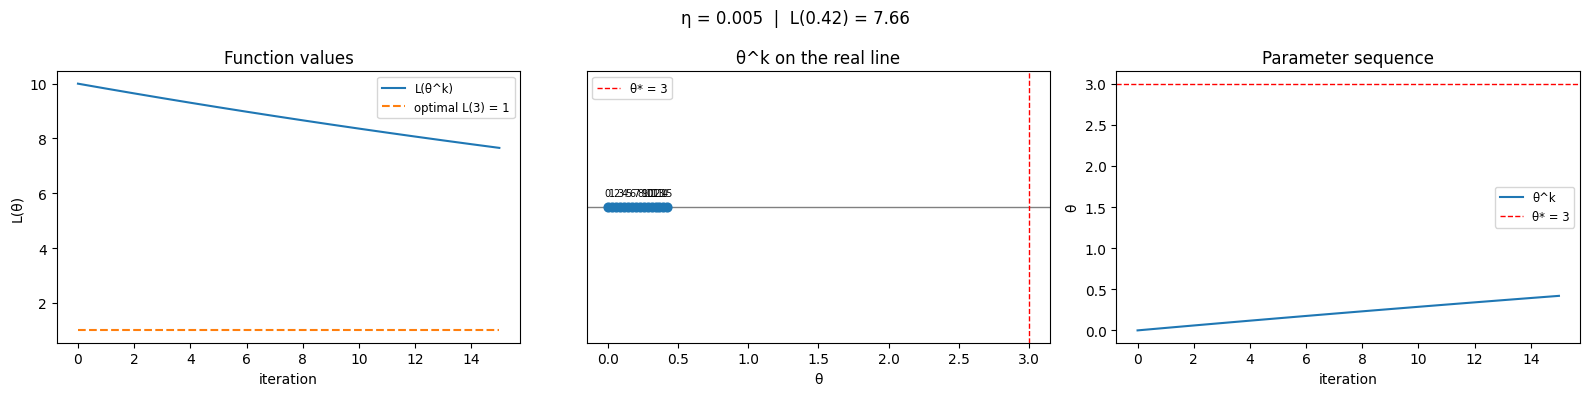

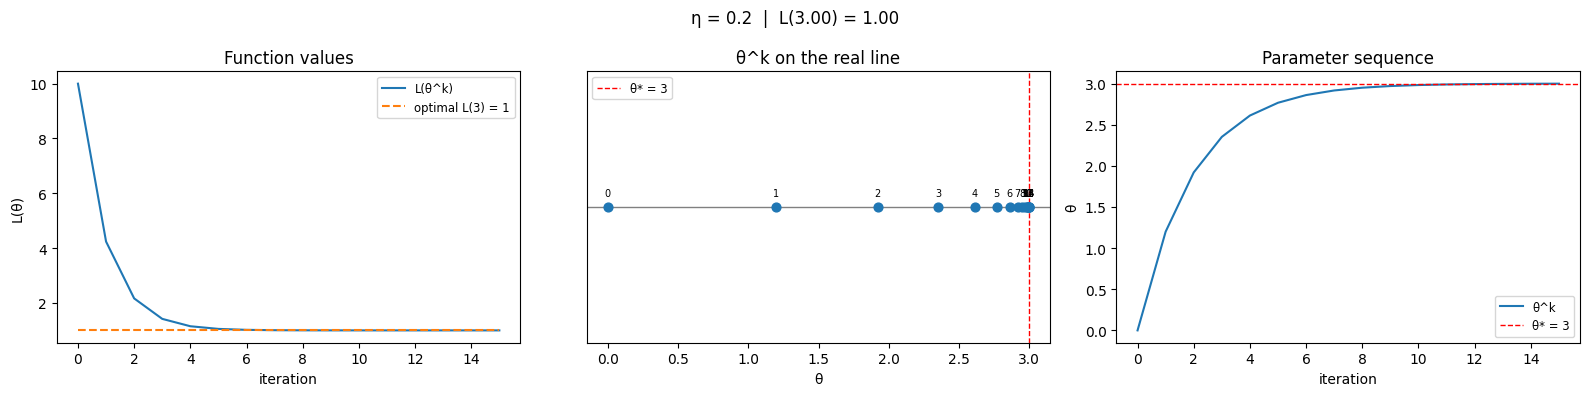

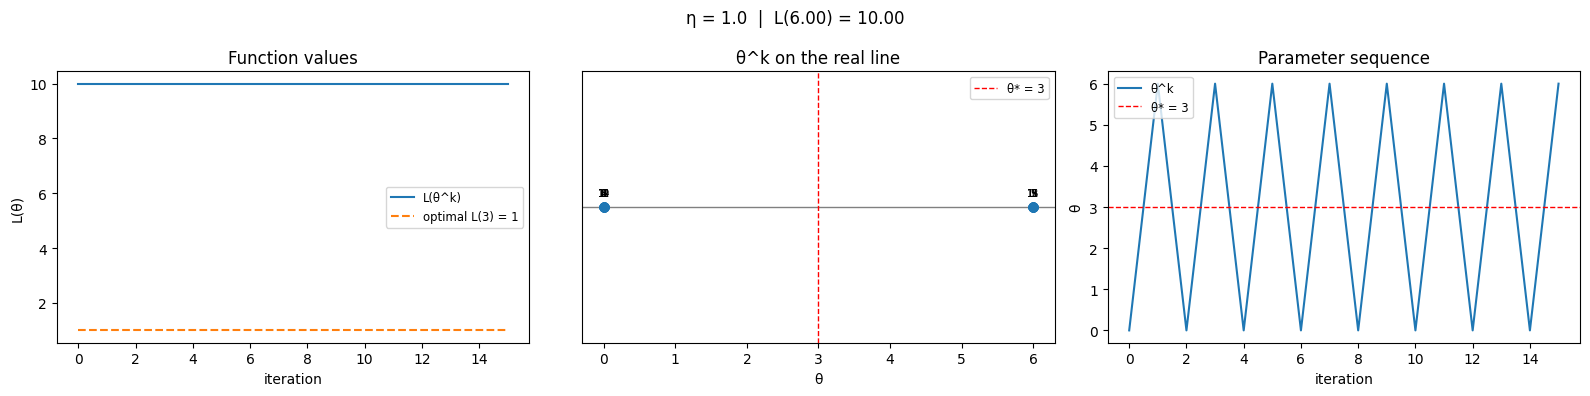

In [4]:
learning_rates = [0.005, 0.2, 1.0]
global_minimum = 3

for eta in learning_rates:
    optimized, params, values = gradient_descent(l, l_prime, eta0=eta, theta0=0, maxit=15)
    optimal_line = len(values) * [l(global_minimum)]

    fig, (ax_loss, ax_line, ax_params) = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"η = {eta}  |  L({optimized:.2f}) = {l(optimized):.2f}", fontsize=12)

    # loss vs iteration
    ax_loss.plot(values, label="L(θ^k)")
    ax_loss.plot(optimal_line, "--", label="optimal L(3) = 1")
    ax_loss.set_xlabel("iteration")
    ax_loss.set_ylabel("L(θ)")
    ax_loss.set_title("Function values")
    ax_loss.legend(fontsize="small")

    # θ^k on the real line
    ax_line.axhline(0, color="gray", linewidth=1)
    ax_line.scatter(params, [0] * len(params), zorder=3, s=40)
    ax_line.axvline(global_minimum, color="red", linestyle="--", linewidth=1, label="θ* = 3")
    for k, p in enumerate(params):
        ax_line.annotate(str(k), (p, 0), textcoords="offset points", xytext=(0, 8),
                         ha="center", fontsize=7)
    ax_line.set_yticks([])
    ax_line.set_xlabel("θ")
    ax_line.set_title("θ^k on the real line")
    ax_line.legend(fontsize="small")

    # θ^k vs iteration
    ax_params.plot(params, label="θ^k")
    ax_params.axhline(global_minimum, color="red", linestyle="--", linewidth=1, label="θ* = 3")
    ax_params.set_xlabel("iteration")
    ax_params.set_ylabel("θ")
    ax_params.set_title("Parameter sequence")
    ax_params.legend(fontsize="small")

    plt.tight_layout()
    plt.show()


$\mathcal{L}$ is strictly convex meaning convergence is guaranteed, given an appropriate step size.

$\eta = 0.005$ is pretty small. Loss decreases monotonically with no oscillations, but the rate is very slow: after 15 iterations the iterates barely move from the initial point.
$\eta = 0.2$ is just right. The sequence converges rapidly to $\Theta^* = 3$ with no oscillations in about 5 iterations.
$\eta = 1.0$ instead is too big. Starting from $\Theta^{(0)} = 0$ the iterates bounce perpetually between $0$ and $6$ without converging.


# Exercise 2

In [5]:
# function definition and its derivative

def l(theta) -> float:
    return theta ** 4 - (3 * theta ** 2) + 2

def l_prime(theta: float) -> float:
    return (4 * theta ** 3) - (6 * theta)


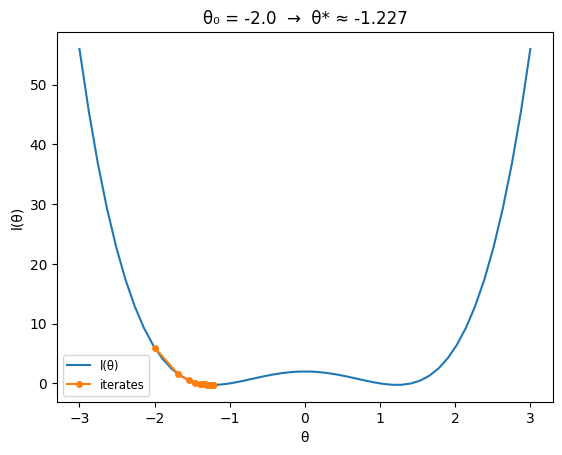

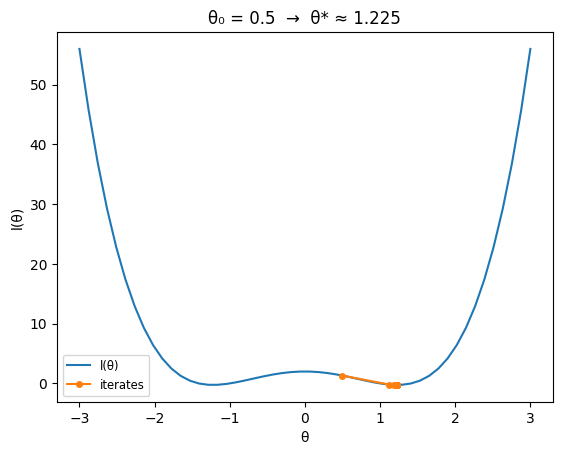

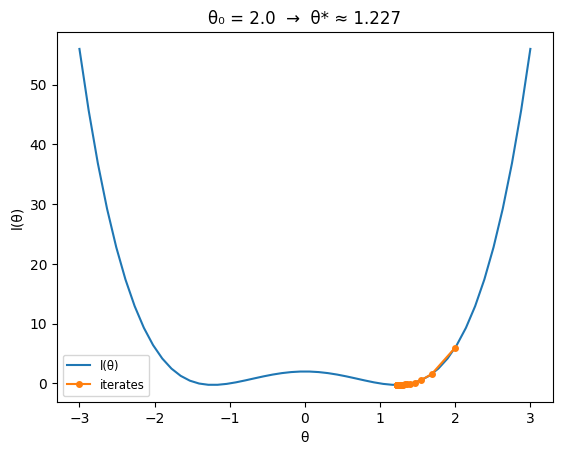

In [6]:
starting_points = [-2.0, 0.5, 2.0]
domain = np.linspace(-3, 3)

for theta0 in starting_points:
    optimized, params, values = gradient_descent(
        l, l_prime,
        eta0=0.5,
        theta0=theta0,
        with_backtracking=True,
        beta=0.5,
        armijo_c=0.5,
    )
    plt.plot(domain, l(domain), label="l(θ)")
    plt.plot(params, values, "o-", markersize=4, label="iterates")
    plt.title(f"θ₀ = {theta0:.1f}  →  θ* ≈ {optimized:.3f}")
    plt.xlabel("θ")
    plt.ylabel("l(θ)")
    plt.legend(fontsize="small")
    plt.show()

This function has two distinct minima. The basin of attraction of each minimum is separated by the ridge at $\Theta = 0$: values $\Theta^{(0)} < 0$ falls into the left basin and converges to $\approx -1.22$, while $\Theta^{(0)} > 0$ (e.g. $0.5$ and $2$) falls into the right basin and converges to $\approx +1.22$.

At each iteration the backtracking procedure starts from an initial $\eta$ and repeatedly shrinks it by factor $\beta = 0.5$ until the Armijo condition is satisfied. This guarantees *sufficient decrease* proportional to the squared gradient norm. Near the minimum the gradient is small and so is the required decrease, allowing larger steps; in regions of high curvature the step is automatically reduced, preventing overshoot without any manual tuning.

A constant $\eta$ that is safe near the minimum is far too aggressive far from it (causing oscillation or divergence), while a constant $\eta$ small enough to be globally safe leads to extremely slow progress near the minimum. Backtracking sidesteps this by adapting the step to the local geometry at every iteration.

# Exercise 3

In [7]:
A = np.array([[1, 0], [0, 25]])

def l(theta):
    """l(theta) := (1/2) * theta^T A theta"""
    theta = np.asarray(theta)
    assert theta.shape == (2,), f"theta must be a 2-dimensional vector, got shape {theta.shape}"
    return 0.5 * theta @ A @ theta

def nabla_l(theta):
    """gradient of l with respect to theta: (1/2)(A + A^T) theta"""
    theta = np.asarray(theta)
    assert theta.shape == (2,), f"theta must be a 2-dimensional vector, got shape {theta.shape}"
    return 0.5 * (A + A.T) @ theta





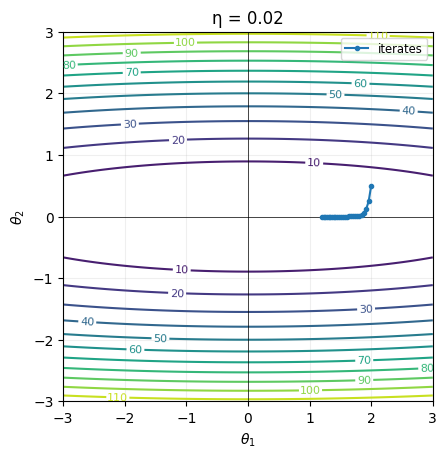

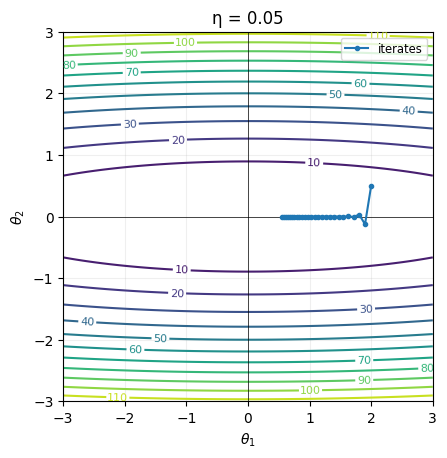

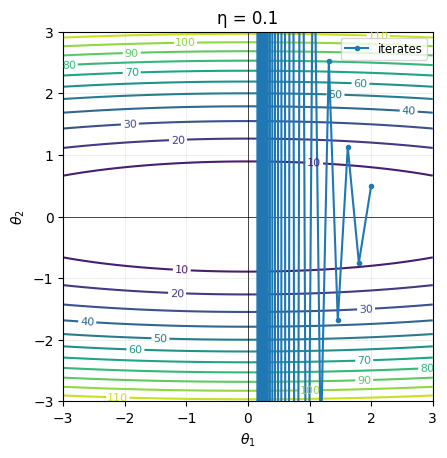

In [8]:
theta0 = np.array([2.0, 0.5])

for eta in [0.02, 0.05, 0.1]:
    _, params, _ = gradient_descent(l, nabla_l, eta0=eta, theta0=theta0)
    params_on_set_level(l, params, title=f"η = {eta}")


The matrix $A = \begin{bmatrix}1 & 0 \\ 0 & 25\end{bmatrix}$ has condition number $\kappa = \lambda_\text{max} / \lambda_\text{min} = 25$. Its level sets are ellipses with semi-axis ratio $\sqrt{25}:\sqrt{1} = 5:1$, elongated along $\theta_1$. This is an ill-conditioned problem as the curvature differs greatly by direction.

The gradient $\nabla l = A\theta = (\theta_1,\, 25\theta_2)^\top$ is always orthogonal to the level sets (by definition), but for anisotropic $A$ it points steeply *across* the narrow axis ($\theta_2$) while barely moving along the shallow axis ($\theta_1$). As a result, most of the step is "wasted" correcting the $\theta_2$ component rather than making progress toward the minimum.

With $\eta = 0.1$ the step taken by GD is too large, so the iterates diverge along $\theta_2$ with exponentially growing oscillations, while $\theta_1$ still contracts minimally.

With $\kappa = 25$, plain gradient descent requires many iterations to traverse the long axis of the valley, because the step size must be kept small enough to avoid divergence along the steep axis. This is exactly the slow-convergence-in-narrow-valleys, and motivates adaptive methods that rescale the gradient direction to account for curvature.

# Exercise 4

In [9]:
A = np.array([[5, 0], [0, 2]])

def l(theta):
    """l(theta) := (1/2) * theta^T A theta"""
    theta = np.asarray(theta)
    assert theta.shape == (2,), f"theta must be a 2-dimensional vector, got shape {theta.shape}"
    return 0.5 * theta @ A @ theta

def nabla_l(theta):
    """gradient of l with respect to theta: (1/2)(A + A^T) theta"""
    theta = np.asarray(theta)
    assert theta.shape == (2,), f"theta must be a 2-dimensional vector, got shape {theta.shape}"
    return 0.5 * (A + A.T) @ theta


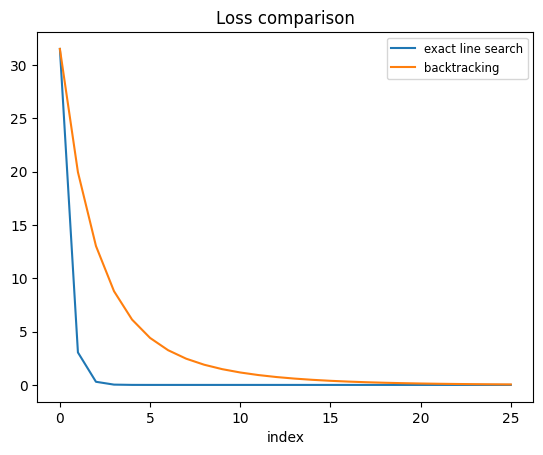

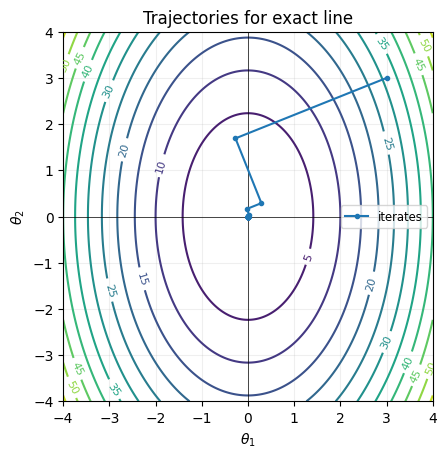

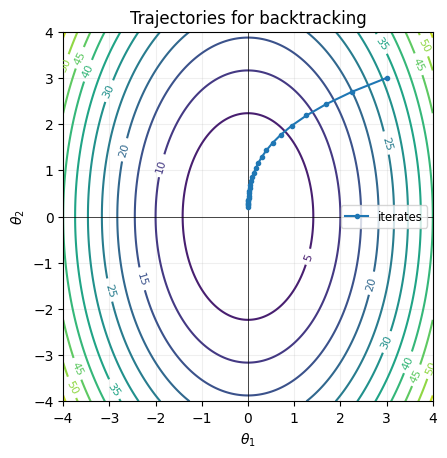

In [10]:
theta0 = np.array([3.0, 3.0])
eta0 = 0.05

_, params_els, losses_els = gradient_descent_exact_ls(l, nabla_l, theta0=theta0)
_, params_bt, losses_bt = gradient_descent(
    l, nabla_l,
    eta0=eta0,
    theta0=theta0,
    with_backtracking=True,
    beta=0.5,
    armijo_c=0.5,
)

plot_series([losses_els, losses_bt], labels=["exact line search", "backtracking"], title="Loss comparison")
params_on_set_level(l, params_els, title=f"Trajectories for exact line", xlim=(-4, 4), ylim=(-4, 4))
params_on_set_level(l, params_bt, title=f"Trajectories for backtracking", xlim=(-4, 4), ylim=(-4, 4))


The optimal step minimises the loss exactly along the gradient direction at every iteration. For a 2D quadratic with a diagonal $A$, exact line search produces conjugate directions and converges to the minimiser in at most 2 iterations (in exact arithmetic). The loss curve drops steeply and gets close to zero in just a few steps; the trajectory on the level-set map makes sharp perpendicular turns and arrives at the origin.

The Armijo-based backtracking only guarantees *sufficient decrease*, not the global minimum along the search direction. It therefore requires more iterations than exact line search. The accepted step sizes vary from iteration to iteration (shrinking when the curvature is underestimated) and are generally smaller than the exact-line-search steps. The trajectory is smoother in appearance but longer in iteration count, and the loss curve decays more gradually.


# Exercise 5

In [11]:
# function definition and its gradient

def l(theta):
    """2-dimensional Rosenbrock"""
    return ((1-theta[0])**2) + (100*((theta[1] -(theta[0]**2))**2))

def nabla_l(theta):
    d0 = (-(2*(1-theta[0]))) + -400*(theta[1] -(theta[0]**2))*theta[0]
    d1 = 200*(theta[1] -(theta[0]**2))
    return np.array([d0, d1])


starting_points = [
    np.array([-1.5, 2]),
    np.array([-1, 0]),
    np.array([0, 2]),
    np.array([1.5, 1.5]),
]

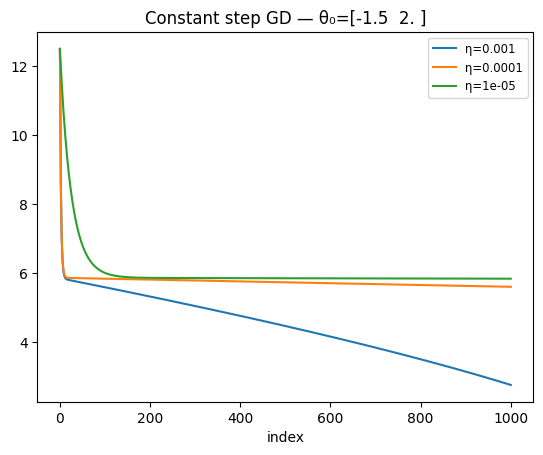

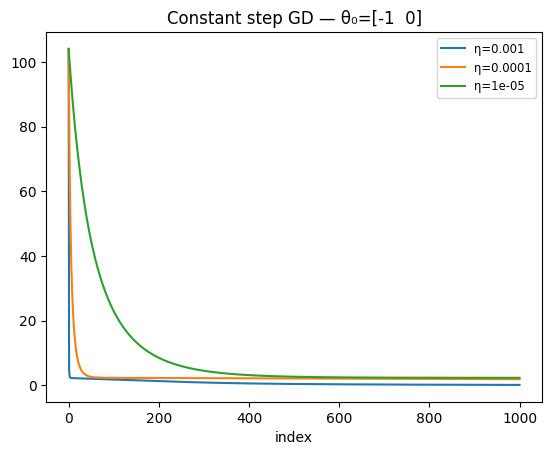

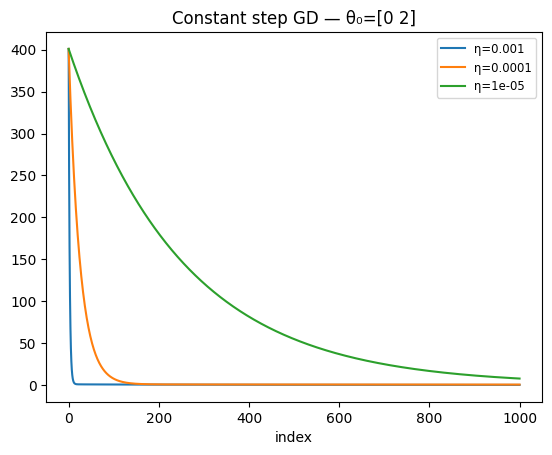

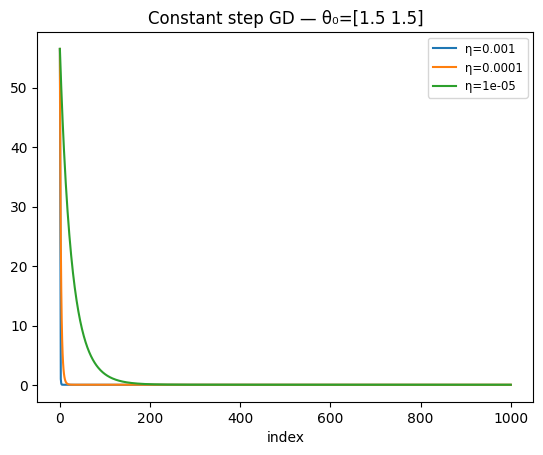

In [12]:
learning_rates = [1e-3, 1e-4, 1e-5]

for theta0 in starting_points:
    loss_series = []
    labels = []
    for eta in learning_rates:
        _, _, losses = gradient_descent(l, nabla_l, eta0=eta, theta0=theta0, maxit=1000)
        loss_series.append(losses)
        labels.append(f"η={eta}")
    plot_series(loss_series, title=f"Constant step GD — θ₀={theta0}", labels=labels)


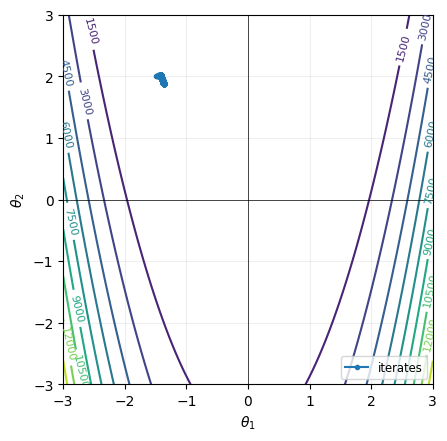

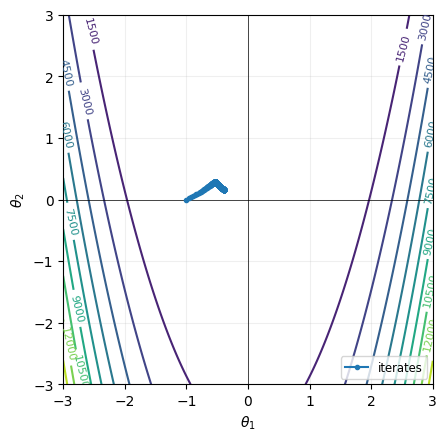

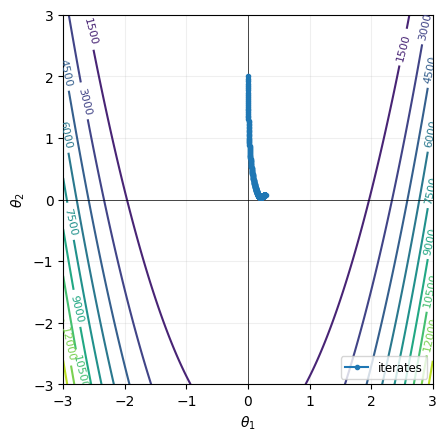

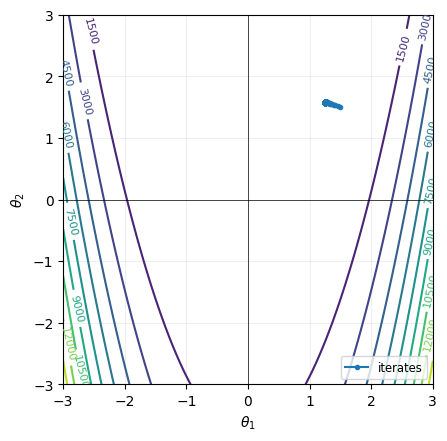

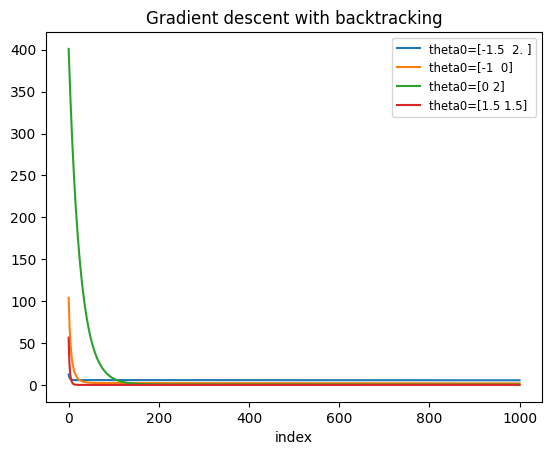

In [13]:
loss_series = []
labels = []

for theta0 in starting_points:
    optimized, params, losses = gradient_descent(
        l, nabla_l,
        eta0=1e-4,
        theta0=theta0,
        with_backtracking=True,
        beta=0.5,
        armijo_c=0.5,
        maxit=1000
    )
    label = f"theta0={theta0}"
    loss_series.append(losses)
    labels.append(label)
    params_on_set_level(l, params)

plot_series(loss_series, title="Gradient descent with backtracking", labels=labels)

Rosenbrock has a long, narrow, curved valley with a condition number up to $10^6$, making it a hard test for gradient descent.

With constant $\eta$, $10^{-3}$ is often unstable (the local Lipschitz constant near some starting points exceeds $1/\eta$), $10^{-4}$ is stable but slow, and $10^{-5}$ is safe but makes negligible progress in 1000 iterations. Once inside the valley, the gradient points almost orthogonally to it, causing persistent zig-zag regardless of step size.

Backtracking handles the variable curvature well — it automatically shrinks the step in steep regions and grows it in flat ones — so all four starting points converge. Zig-zagging still occurs but remains bounded. Both methods are fundamentally limited by not adapting the gradient *direction*, which is why methods like Adam or quasi-Newton are preferred on this function.